# DS605 | LAB-05 | Linear and Logistic Regression | 202618042

In [1]:
import pandas as pd
import numpy as np

import time

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load dataset
df = pd.read_csv("garments_worker_productivity.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1197, 15)


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (1197, 15)

Columns:
['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']

Data types:
date                         str
quarter                      str
department                   str
day                          str
team                       int64
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                  int64
incentive                  int64
idle_time                float64
idle_men                   int64
no_of_style_change         int64
no_of_workers            float64
actual_productivity      float64
dtype: object

Missing values:
date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,1197,59,1/31/2015,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quarter,1197,5,Quarter1,360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,1197,3,sweing,691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,1197,6,Wednesday,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team,1197.0,NaN,NaN,NaN,6.426901,3.463963,1.0,3.0,6.0,9.0,12.0
targeted_productivity,1197.0,NaN,NaN,NaN,0.729632,0.097891,0.07,0.7,0.75,0.8,0.8
smv,1197.0,NaN,NaN,NaN,15.062172,10.943219,2.9,3.94,15.26,24.26,54.56
wip,691.0,NaN,NaN,NaN,1190.465991,1837.455001,7.0,774.5,1039.0,1252.5,23122.0
over_time,1197.0,NaN,NaN,NaN,4567.460317,3348.823563,0.0,1440.0,3960.0,6960.0,25920.0
incentive,1197.0,NaN,NaN,NaN,38.210526,160.182643,0.0,0.0,0.0,50.0,3600.0


##### Classification Target

In [4]:
df["MeetsTarget"] = (
    df["actual_productivity"] >= df["targeted_productivity"]
).astype(int)

print(df[[
    "actual_productivity",
    "targeted_productivity",
    "MeetsTarget"
]].head(10))

   actual_productivity  targeted_productivity  MeetsTarget
0             0.940725                   0.80            1
1             0.886500                   0.75            1
2             0.800570                   0.80            1
3             0.800570                   0.80            1
4             0.800382                   0.80            1
5             0.800125                   0.80            1
6             0.755167                   0.75            1
7             0.753683                   0.75            1
8             0.753098                   0.75            1
9             0.750428                   0.75            1


In [5]:
regression_target = "actual_productivity"
classification_target = "MeetsTarget"

print("Regression target:", regression_target)
print("Classification target:", classification_target)

Regression target: actual_productivity
Classification target: MeetsTarget


In [6]:
# Regression
X_reg = df.drop(columns=["actual_productivity", "MeetsTarget"])
y_reg = df["actual_productivity"]

# Classification
X_clf = df.drop(columns=["actual_productivity", "MeetsTarget"])
y_clf = df["MeetsTarget"]

print("Regression X shape:", X_reg.shape)
print("Regression y shape:", y_reg.shape)

print("Classification X shape:", X_clf.shape)
print("Classification y shape:", y_clf.shape)

Regression X shape: (1197, 14)
Regression y shape: (1197,)
Classification X shape: (1197, 14)
Classification y shape: (1197,)


##### Splitting training and test data 

In [7]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_reg,
    y_reg,
    y_clf,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 957
Testing rows: 240


In [9]:
categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['date', 'quarter', 'department', 'day']

Numerical features:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


In [10]:
for split in [X_train, X_test]:
    split["department"] = split["department"].str.strip()
    split["date"] = pd.to_datetime(split["date"])
    split["month"] = split["date"].dt.month.astype("int64")

X_train = X_train.drop(columns=["date"])
X_test = X_test.drop(columns=["date"])

# wip is 42% missing -> flag missingness before imputing, since it may
# be structurally missing (e.g. only recorded for certain departments)
X_train["wip_was_missing"] = X_train["wip"].isnull().astype(int)
X_test["wip_was_missing"] = X_test["wip"].isnull().astype(int)

print(X_train[["department", "month", "wip_was_missing"]].head())
print("\nWIP missing % in train:", X_train["wip"].isnull().mean() * 100)

     department  month  wip_was_missing
1189     sweing      3                0
575   finishing      2                1
76    finishing      1                1
731   finishing      2                1
138      sweing      1                0

WIP missing % in train: 43.364681295715776


In [11]:
# Refresh feature lists after cleaning (date is gone, month is new)

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# wip gets its own branch (missing values + log transform), so keep it
# out of the general numerical list
numerical_features.remove("wip")

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)

Categorical features: ['quarter', 'department', 'day']

Numerical features: ['team', 'targeted_productivity', 'smv', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'month', 'wip_was_missing']


### Pre-Processing Pipeline

In [12]:
from sklearn.preprocessing import FunctionTransformer

# wip: 42% missing, heavily right-skewed (max >> median) -> median impute + log1p + scale
wip_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=True, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

# general numeric columns -> simple median impute + scale
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical columns (quarter, department, day) -> most frequent impute + one-hot
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("wip", wip_pipeline, ["wip"]),
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('wip', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [13]:
# Fit on training data only, transform both train and test
# (prevents test-set information leaking into imputation/scaling)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train shape after preprocessing:", X_train_processed.shape)
print("Test shape after preprocessing:", X_test_processed.shape)

feature_names_out = preprocessor.get_feature_names_out()
print("\nFeature names:", feature_names_out)

Train shape after preprocessing: (957, 22)
Test shape after preprocessing: (240, 22)

Feature names: ['wip__wip' 'num__team' 'num__targeted_productivity' 'num__smv'
 'num__over_time' 'num__incentive' 'num__idle_time' 'num__idle_men'
 'num__no_of_style_change' 'num__no_of_workers' 'num__month'
 'num__wip_was_missing' 'cat__quarter_Quarter2' 'cat__quarter_Quarter3'
 'cat__quarter_Quarter4' 'cat__quarter_Quarter5' 'cat__department_sweing'
 'cat__day_Saturday' 'cat__day_Sunday' 'cat__day_Thursday'
 'cat__day_Tuesday' 'cat__day_Wednesday']


In [14]:
from sklearn.linear_model import LinearRegression, LogisticRegression
import time

lin_reg = LinearRegression()

start = time.time()
lin_reg.fit(X_train_processed, y_reg_train)
lin_reg_train_time = time.time() - start

start = time.time()
y_reg_pred = lin_reg.predict(X_test_processed)
lin_reg_predict_time = time.time() - start

print("LinearRegression training time:", lin_reg_train_time, "s")
print("LinearRegression prediction time:", lin_reg_predict_time, "s")

LinearRegression training time: 0.016820192337036133 s
LinearRegression prediction time: 0.0006937980651855469 s


In [15]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

start = time.time()
log_reg.fit(X_train_processed, y_clf_train)
log_reg_train_time = time.time() - start

start = time.time()
y_clf_pred = log_reg.predict(X_test_processed)
log_reg_predict_time = time.time() - start

print("LogisticRegression training time:", log_reg_train_time, "s")
print("LogisticRegression prediction time:", log_reg_predict_time, "s")

LogisticRegression training time: 0.0197141170501709 s
LogisticRegression prediction time: 0.0011556148529052734 s


##### Regression Metrics

In [16]:
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.1076558656274699
RMSE: 0.14772188437016295
R2: 0.17816466871506154


##### Classification Metrics

In [17]:
acc = accuracy_score(y_clf_test, y_clf_pred)
prec = precision_score(y_clf_test, y_clf_pred)
rec = recall_score(y_clf_test, y_clf_pred)
f1 = f1_score(y_clf_test, y_clf_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

Accuracy: 0.7583333333333333
Precision: 0.771689497716895
Recall: 0.9548022598870056
F1-score: 0.8535353535353535


In [18]:
sklearn_results = {
    "regression": {
        "MAE": mae, "RMSE": rmse, "R2": r2,
        "train_time": lin_reg_train_time, "predict_time": lin_reg_predict_time
    },
    "classification": {
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1,
        "train_time": log_reg_train_time, "predict_time": log_reg_predict_time
    }
}
print(sklearn_results)

{'regression': {'MAE': 0.1076558656274699, 'RMSE': np.float64(0.14772188437016295), 'R2': 0.17816466871506154, 'train_time': 0.016820192337036133, 'predict_time': 0.0006937980651855469}, 'classification': {'Accuracy': 0.7583333333333333, 'Precision': 0.771689497716895, 'Recall': 0.9548022598870056, 'F1': 0.8535353535353535, 'train_time': 0.0197141170501709, 'predict_time': 0.0011556148529052734}}


## Part B
### Implementation using NumPy/Pandas only, no scikit-learn
### Manual Preprocessing

In [20]:
wip_median_train = X_train["wip"].median()

X_train_manual = X_train.copy()
X_test_manual = X_test.copy()

X_train_manual["wip"] = X_train_manual["wip"].fillna(wip_median_train)
X_test_manual["wip"] = X_test_manual["wip"].fillna(wip_median_train)

print("WIP median used for imputation", wip_median_train)

WIP median used for imputation 1023.0


##### log transform + robust scaling for wip

In [21]:
X_train_manual["wip"] = np.log1p(X_train_manual["wip"])
X_test_manual["wip"] = np.log1p(X_test_manual["wip"])

wip_median_log = X_train_manual["wip"].median()
wip_q1 = X_train_manual["wip"].quantile(0.25)
wip_q3 = X_train_manual["wip"].quantile(0.75)
wip_iqr = wip_q3 - wip_q1

X_train_manual["wip"] = (X_train_manual["wip"] - wip_median_log) / wip_iqr
X_test_manual["wip"] = (X_test_manual["wip"] - wip_median_log) / wip_iqr

print("WIP robust-scaling stats -> median:", wip_median_log, "IQR:", wip_iqr)

WIP robust-scaling stats -> median: 6.931471805599453 IQR: 0.10047814996276738


##### Frequency encoding for 'team'

In [22]:
team_freq_map = X_train_manual["team"].value_counts(normalize=True).to_dict()

X_train_manual["team"] = X_train_manual["team"].map(team_freq_map)
X_test_manual["team"] = X_test_manual["team"].map(team_freq_map).fillna(0)  # unseen team -> 0

print("Team frequency map (from train only):")
print(team_freq_map)

Team frequency map (from train only):
{2: 0.09926854754440961, 4: 0.09090909090909091, 8: 0.08986415882967608, 12: 0.0877742946708464, 9: 0.08463949843260188, 3: 0.08463949843260188, 1: 0.08359456635318704, 7: 0.08359456635318704, 6: 0.07836990595611286, 5: 0.0741901776384535, 10: 0.07210031347962383, 11: 0.07105538140020899}


##### standard scaling for remaining numeric columns

In [23]:
numeric_cols_manual = [
    "targeted_productivity", "smv", "over_time", "incentive",
    "idle_time", "idle_men", "no_of_style_change", "no_of_workers",
    "month", "wip_was_missing"
]

scaling_stats = {}
for col in numeric_cols_manual:
    mean_val = X_train_manual[col].mean()
    std_val = X_train_manual[col].std()
    scaling_stats[col] = (mean_val, std_val)

    X_train_manual[col] = (X_train_manual[col] - mean_val) / std_val
    X_test_manual[col] = (X_test_manual[col] - mean_val) / std_val

print(scaling_stats)

{'targeted_productivity': (np.float64(0.7279205851619645), np.float64(0.1008507844093204)), 'smv': (np.float64(14.847450365726228), np.float64(10.946357276958608)), 'over_time': (np.float64(4482.842215256009), np.float64(3353.0503924461013)), 'incentive': (np.float64(39.88296760710554), np.float64(175.8798708406289)), 'idle_time': (np.float64(0.31191222570532917), np.float64(5.6786453280832845)), 'idle_men': (np.float64(0.3500522466039707), np.float64(3.0865704006666723)), 'no_of_style_change': (np.float64(0.15569487983281086), np.float64(0.42882717220855315)), 'no_of_workers': (np.float64(33.87147335423197), np.float64(22.175689014937227)), 'month': (np.float64(1.7429467084639498), np.float64(0.7534890185874887)), 'wip_was_missing': (np.float64(0.4336468129571578), np.float64(0.4958368234239552))}


##### Manual One-hot encoding

In [24]:
categorical_cols_manual = ["quarter", "department", "day"]

def manual_one_hot(train_col, test_col, col_name):
    categories = sorted(train_col.unique())
    categories_to_encode = categories[1:]  # drop first, avoids multicollinearity

    train_encoded = pd.DataFrame({
        f"{col_name}_{cat}": (train_col == cat).astype(int)
        for cat in categories_to_encode
    }, index=train_col.index)

    test_encoded = pd.DataFrame({
        f"{col_name}_{cat}": (test_col == cat).astype(int)
        for cat in categories_to_encode
    }, index=test_col.index)

    return train_encoded, test_encoded

encoded_train_parts, encoded_test_parts = [], []
for col in categorical_cols_manual:
    train_enc, test_enc = manual_one_hot(X_train_manual[col], X_test_manual[col], col)
    encoded_train_parts.append(train_enc)
    encoded_test_parts.append(test_enc)

X_train_encoded = pd.concat(encoded_train_parts, axis=1)
X_test_encoded = pd.concat(encoded_test_parts, axis=1)

print(X_train_encoded.columns.tolist())

['quarter_Quarter2', 'quarter_Quarter3', 'quarter_Quarter4', 'quarter_Quarter5', 'department_sweing', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']


##### Combine into final matrices + add bias column:

In [25]:
numeric_final_cols = ["wip", "team"] + numeric_cols_manual

X_train_final = pd.concat([X_train_manual[numeric_final_cols], X_train_encoded], axis=1)
X_test_final = pd.concat([X_test_manual[numeric_final_cols], X_test_encoded], axis=1)

X_train_manual_np = X_train_final.to_numpy(dtype=float)
X_test_manual_np = X_test_final.to_numpy(dtype=float)

# manually add bias/intercept column of 1s (sklearn does this internally)
X_train_manual_np = np.hstack([np.ones((X_train_manual_np.shape[0], 1)), X_train_manual_np])
X_test_manual_np = np.hstack([np.ones((X_test_manual_np.shape[0], 1)), X_test_manual_np])

print("Manual X_train shape:", X_train_manual_np.shape)
print("Manual X_test shape:", X_test_manual_np.shape)

Manual X_train shape: (957, 23)
Manual X_test shape: (240, 23)


In [26]:
y_reg_train_np = y_reg_train.to_numpy(dtype=float)
y_reg_test_np = y_reg_test.to_numpy(dtype=float)
y_clf_train_np = y_clf_train.to_numpy(dtype=float)
y_clf_test_np = y_clf_test.to_numpy(dtype=float)

print("y_reg_train_np shape:", y_reg_train_np.shape)
print("y_clf_train_np shape:", y_clf_train_np.shape)

y_reg_train_np shape: (957,)
y_clf_train_np shape: (957,)


#### Manual Linear Regression (closed-form normal equation), timed

In [27]:
import time

start = time.time()
# theta = (X^T X)^-1 X^T y  -> pseudo-inverse for numerical stability
XtX = X_train_manual_np.T @ X_train_manual_np
Xty = X_train_manual_np.T @ y_reg_train_np
theta_linear = np.linalg.pinv(XtX) @ Xty
manual_lin_train_time = time.time() - start

print("Manual LinearRegression training time:", manual_lin_train_time, "s")
print("theta shape:", theta_linear.shape)

Manual LinearRegression training time: 0.0032444000244140625 s
theta shape: (23,)


#### Predict

In [28]:
start = time.time()
y_reg_pred_manual = X_test_manual_np @ theta_linear
manual_lin_predict_time = time.time() - start

print("Manual LinearRegression prediction time:", manual_lin_predict_time, "s")

Manual LinearRegression prediction time: 0.0001742839813232422 s


#### Manual Regression Metrices

In [29]:
def manual_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def manual_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def manual_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

mae_manual = manual_mae(y_reg_test_np, y_reg_pred_manual)
rmse_manual = manual_rmse(y_reg_test_np, y_reg_pred_manual)
r2_manual = manual_r2(y_reg_test_np, y_reg_pred_manual)

print("Manual MAE:", mae_manual)
print("Manual RMSE:", rmse_manual)
print("Manual R2:", r2_manual)

Manual MAE: 0.10918246405469971
Manual RMSE: 0.14818640835054128
Manual R2: 0.17298788041785018


#### Manual Logistic Regression

In [31]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic_regression(X, y, lr=0.1, n_iters=2000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)

    for i in range(n_iters):
        linear_output = X @ weights
        y_pred = sigmoid(linear_output)
        gradient = (X.T @ (y_pred - y)) / n_samples
        weights -= lr * gradient

    return weights

start = time.time()
weights_logistic = train_logistic_regression(X_train_manual_np, y_clf_train_np, lr=0.1, n_iters=2000)
manual_log_train_time = time.time() - start

print("Manual LogisticRegression training time:", manual_log_train_time, "s")

Manual LogisticRegression training time: 0.05478668212890625 s


#### Predict (sigmoid + 0.5 threshold)

In [32]:
start = time.time()
y_clf_proba_manual = sigmoid(X_test_manual_np @ weights_logistic)
y_clf_pred_manual = (y_clf_proba_manual >= 0.5).astype(int)
manual_log_predict_time = time.time() - start

print("Manual LogisticRegression prediction time:", manual_log_predict_time, "s")

Manual LogisticRegression prediction time: 0.00033092498779296875 s


#### Classification Metrics

In [33]:
def manual_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def manual_precision(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def manual_recall(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def manual_f1(y_true, y_pred):
    p = manual_precision(y_true, y_pred)
    r = manual_recall(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

acc_manual = manual_accuracy(y_clf_test_np, y_clf_pred_manual)
prec_manual = manual_precision(y_clf_test_np, y_clf_pred_manual)
rec_manual = manual_recall(y_clf_test_np, y_clf_pred_manual)
f1_manual = manual_f1(y_clf_test_np, y_clf_pred_manual)

print("Manual Accuracy:", acc_manual)
print("Manual Precision:", prec_manual)
print("Manual Recall:", rec_manual)
print("Manual F1-score:", f1_manual)

Manual Accuracy: 0.75
Manual Precision: 0.7577092511013216
Manual Recall: 0.9717514124293786
Manual F1-score: 0.8514851485148516


In [34]:
manual_results = {
    "regression": {
        "MAE": mae_manual, "RMSE": rmse_manual, "R2": r2_manual,
        "train_time": manual_lin_train_time, "predict_time": manual_lin_predict_time
    },
    "classification": {
        "Accuracy": acc_manual, "Precision": prec_manual, "Recall": rec_manual, "F1": f1_manual,
        "train_time": manual_log_train_time, "predict_time": manual_log_predict_time
    }
}
print(manual_results)

{'regression': {'MAE': np.float64(0.10918246405469971), 'RMSE': np.float64(0.14818640835054128), 'R2': np.float64(0.17298788041785018), 'train_time': 0.0032444000244140625, 'predict_time': 0.0001742839813232422}, 'classification': {'Accuracy': np.float64(0.75), 'Precision': np.float64(0.7577092511013216), 'Recall': np.float64(0.9717514124293786), 'F1': np.float64(0.8514851485148516), 'train_time': 0.05478668212890625, 'predict_time': 0.00033092498779296875}}


## Part C - Comparison and Optimization

In [35]:
X_train_opt = X_train.copy()
X_test_opt = X_test.copy()

for split in [X_train_opt, X_test_opt]:
    split["overtime_per_worker"] = split["over_time"] / split["no_of_workers"].replace(0, np.nan)
    split["incentive_per_worker"] = split["incentive"] / split["no_of_workers"].replace(0, np.nan)
    split["overtime_per_worker"] = split["overtime_per_worker"].fillna(0)
    split["incentive_per_worker"] = split["incentive_per_worker"].fillna(0)

# reapply wip and team preprocessing from Part B (same logic, new dataframe)
wip_median_train = X_train_opt["wip"].median()
X_train_opt["wip"] = X_train_opt["wip"].fillna(wip_median_train)
X_test_opt["wip"] = X_test_opt["wip"].fillna(wip_median_train)
X_train_opt["wip"] = np.log1p(X_train_opt["wip"])
X_test_opt["wip"] = np.log1p(X_test_opt["wip"])

team_freq_map = X_train_opt["team"].value_counts(normalize=True).to_dict()
X_train_opt["team"] = X_train_opt["team"].map(team_freq_map)
X_test_opt["team"] = X_test_opt["team"].map(team_freq_map).fillna(0)

print(X_train_opt[["overtime_per_worker", "incentive_per_worker"]].describe())

       overtime_per_worker  incentive_per_worker
count           957.000000            957.000000
mean            149.371961              1.882425
std              89.455841             14.933678
min               0.000000              0.000000
25%             120.000000              0.000000
50%             120.000000              0.000000
75%             180.000000              0.909091
max             720.000000            240.000000


In [36]:
candidate_numeric_cols = [
    "wip", "team", "targeted_productivity", "smv", "over_time", "incentive",
    "idle_time", "idle_men", "no_of_style_change", "no_of_workers", "month",
    "wip_was_missing", "overtime_per_worker", "incentive_per_worker"
]

corr_check = X_train_opt[candidate_numeric_cols].copy()
corr_check["actual_productivity"] = y_reg_train_np
correlations = corr_check.corr()["actual_productivity"].drop("actual_productivity").sort_values(key=abs, ascending=False)
print(correlations)

targeted_productivity    0.431037
no_of_style_change      -0.212743
idle_men                -0.202731
wip                      0.176832
team                     0.142326
smv                     -0.117555
month                   -0.097705
idle_time               -0.086370
wip_was_missing          0.081632
incentive                0.066243
no_of_workers           -0.057404
over_time               -0.051634
overtime_per_worker     -0.038800
incentive_per_worker     0.014762
Name: actual_productivity, dtype: float64


In [37]:
CORR_THRESHOLD = 0.10
selected_features = correlations[abs(correlations) >= CORR_THRESHOLD].index.tolist()
dropped_features = correlations[abs(correlations) < CORR_THRESHOLD].index.tolist()

print("Selected numeric features (|corr| >=", CORR_THRESHOLD, "):", selected_features)
print("\nDropped numeric features (weak signal):", dropped_features)

Selected numeric features (|corr| >= 0.1 ): ['targeted_productivity', 'no_of_style_change', 'idle_men', 'wip', 'team', 'smv']

Dropped numeric features (weak signal): ['month', 'idle_time', 'wip_was_missing', 'incentive', 'no_of_workers', 'over_time', 'overtime_per_worker', 'incentive_per_worker']


In [38]:
X_train_final_opt = X_train_opt.copy()
X_test_final_opt = X_test_opt.copy()

if "wip" in selected_features:
    wip_median_log = X_train_final_opt["wip"].median()
    wip_iqr = X_train_final_opt["wip"].quantile(0.75) - X_train_final_opt["wip"].quantile(0.25)
    X_train_final_opt["wip"] = (X_train_final_opt["wip"] - wip_median_log) / wip_iqr
    X_test_final_opt["wip"] = (X_test_final_opt["wip"] - wip_median_log) / wip_iqr

other_numeric_selected = [c for c in selected_features if c not in ["wip", "team"]]
for col in other_numeric_selected:
    mean_val = X_train_final_opt[col].mean()
    std_val = X_train_final_opt[col].std()
    X_train_final_opt[col] = (X_train_final_opt[col] - mean_val) / std_val
    X_test_final_opt[col] = (X_test_final_opt[col] - mean_val) / std_val

categorical_cols_manual = ["quarter", "department", "day"]

def manual_one_hot(train_col, test_col, col_name):
    categories = sorted(train_col.unique())
    categories_to_encode = categories[1:]
    train_encoded = pd.DataFrame({
        f"{col_name}_{cat}": (train_col == cat).astype(int)
        for cat in categories_to_encode
    }, index=train_col.index)
    test_encoded = pd.DataFrame({
        f"{col_name}_{cat}": (test_col == cat).astype(int)
        for cat in categories_to_encode
    }, index=test_col.index)
    return train_encoded, test_encoded

encoded_train_parts, encoded_test_parts = [], []
for col in categorical_cols_manual:
    train_enc, test_enc = manual_one_hot(X_train_final_opt[col], X_test_final_opt[col], col)
    encoded_train_parts.append(train_enc)
    encoded_test_parts.append(test_enc)

X_train_encoded_opt = pd.concat(encoded_train_parts, axis=1)
X_test_encoded_opt = pd.concat(encoded_test_parts, axis=1)

In [39]:
X_train_opt_final_df = pd.concat([X_train_final_opt[selected_features], X_train_encoded_opt], axis=1)
X_test_opt_final_df = pd.concat([X_test_final_opt[selected_features], X_test_encoded_opt], axis=1)

X_train_opt_np = X_train_opt_final_df.to_numpy(dtype=float)
X_test_opt_np = X_test_opt_final_df.to_numpy(dtype=float)

X_train_opt_np = np.hstack([np.ones((X_train_opt_np.shape[0], 1)), X_train_opt_np])
X_test_opt_np = np.hstack([np.ones((X_test_opt_np.shape[0], 1)), X_test_opt_np])

print("Optimized X_train shape:", X_train_opt_np.shape, "(original manual had 23 columns)")
print("Optimized X_test shape:", X_test_opt_np.shape)

Optimized X_train shape: (957, 17) (original manual had 23 columns)
Optimized X_test shape: (240, 17)


In [44]:
start = time.time()
XtX_opt = X_train_opt_np.T @ X_train_opt_np
Xty_opt = X_train_opt_np.T @ y_reg_train_np
theta_linear_opt = np.linalg.pinv(XtX_opt) @ Xty_opt
opt_lin_train_time = time.time() - start

start = time.time()
y_reg_pred_opt = X_test_opt_np @ theta_linear_opt
opt_lin_predict_time = time.time() - start

mae_opt = manual_mae(y_reg_test_np, y_reg_pred_opt)
rmse_opt = manual_rmse(y_reg_test_np, y_reg_pred_opt)
r2_opt = manual_r2(y_reg_test_np, y_reg_pred_opt)

print("Optimized LinearRegression training time:", opt_lin_train_time)
print("Optimized LinearRegression prediction time:", opt_lin_predict_time)
print("Optimized MAE:", mae_opt, "RMSE:", rmse_opt, "R2:", r2_opt)

Optimized LinearRegression training time: 0.001300811767578125
Optimized LinearRegression prediction time: 0.00012755393981933594
Optimized MAE: 0.11109172370569796 RMSE: 0.1509891243230638 R2: 0.1414087409331497


In [58]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, weights):
    eps = 1e-10
    y_pred = sigmoid(X @ weights)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

def train_logistic_regression_tuned(X, y, lr=0.1, max_iters=2000, tol=1e-4, check_every=10):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    cost_history = []
    prev_cost = None

    for i in range(max_iters):
        y_pred = sigmoid(X @ weights)
        gradient = (X.T @ (y_pred - y)) / n_samples
        weights -= lr * gradient

        # only compute the expensive cost function every `check_every` iterations,
        # not every single step -- this avoids the tracking overhead outweighing
        # the savings from stopping early
        if i % check_every == 0:
            cost = compute_cost(X, y, weights)
            cost_history.append(cost)
            if prev_cost is not None and abs(prev_cost - cost) < tol:
                print(f"Converged early at iteration {i} (checked every {check_every} iters)")
                break
            prev_cost = cost

    return weights, cost_history

start = time.time()
weights_opt, cost_history = train_logistic_regression_tuned(
    X_train_opt_np, y_clf_train_np, lr=0.1, max_iters=2000, tol=1e-4, check_every=10
)
opt_log_train_time = time.time() - start

print("Optimized LogisticRegression training time:", opt_log_train_time, "s")
print("Iterations actually used:", (len(cost_history) - 1) * 10 + 1, "vs original fixed 2000")

Converged early at iteration 930 (checked every 10 iters)
Optimized LogisticRegression training time: 0.03175163269042969 s
Iterations actually used: 931 vs original fixed 2000


In [59]:
start = time.time()
y_clf_proba_opt = sigmoid(X_test_opt_np @ weights_opt)
y_clf_pred_opt = (y_clf_proba_opt >= 0.5).astype(int)
opt_log_predict_time = time.time() - start

acc_opt = manual_accuracy(y_clf_test_np, y_clf_pred_opt)
prec_opt = manual_precision(y_clf_test_np, y_clf_pred_opt)
rec_opt = manual_recall(y_clf_test_np, y_clf_pred_opt)
f1_opt = manual_f1(y_clf_test_np, y_clf_pred_opt)

print("Optimized LogisticRegression prediction time:", opt_log_predict_time)
print("Optimized Accuracy:", acc_opt, "Precision:", prec_opt, "Recall:", rec_opt, "F1:", f1_opt)

Optimized LogisticRegression prediction time: 0.00020003318786621094
Optimized Accuracy: 0.75 Precision: 0.7532467532467533 Recall: 0.9830508474576272 F1: 0.8529411764705883


In [66]:
optimized_results = {
    "regression": {
        "MAE": mae_opt, "RMSE": rmse_opt, "R2": r2_opt,
        "train_time": opt_lin_train_time, "predict_time": opt_lin_predict_time
    },
    "classification": {
        "Accuracy": acc_opt, "Precision": prec_opt, "Recall": rec_opt, "F1": f1_opt,
        "train_time": opt_log_train_time, "predict_time": opt_log_predict_time,
        "iterations_used": (len(cost_history) - 1) * 10 + 1
    }
}
print(optimized_results)

{'regression': {'MAE': np.float64(0.11109172370569796), 'RMSE': np.float64(0.1509891243230638), 'R2': np.float64(0.1414087409331497), 'train_time': 0.001300811767578125, 'predict_time': 0.00012755393981933594}, 'classification': {'Accuracy': np.float64(0.75), 'Precision': np.float64(0.7532467532467533), 'Recall': np.float64(0.9830508474576272), 'F1': np.float64(0.8529411764705883), 'train_time': 0.03175163269042969, 'predict_time': 0.00020003318786621094, 'iterations_used': 931}}


In [67]:
regression_comparison = pd.DataFrame({
    "Sklearn": sklearn_results["regression"],
    "Manual": manual_results["regression"],
    "Optimized Manual": optimized_results["regression"]
}).T

print(regression_comparison)

                       MAE      RMSE        R2  train_time  predict_time
Sklearn           0.107656  0.147722  0.178165    0.016820      0.000694
Manual            0.109182  0.148186  0.172988    0.003244      0.000174
Optimized Manual  0.111092  0.150989  0.141409    0.001301      0.000128


In [68]:
classification_comparison = pd.DataFrame({
    "Sklearn": sklearn_results["classification"],
    "Manual": manual_results["classification"],
    "Optimized Manual": {k: v for k, v in optimized_results["classification"].items() if k != "iterations_used"}
}).T

print(classification_comparison)

                  Accuracy  Precision    Recall        F1  train_time  \
Sklearn           0.758333   0.771689  0.954802  0.853535    0.019714   
Manual            0.750000   0.757709  0.971751  0.851485    0.054787   
Optimized Manual  0.750000   0.753247  0.983051  0.852941    0.031752   

                  predict_time  
Sklearn               0.001156  
Manual                0.000331  
Optimized Manual      0.000200  


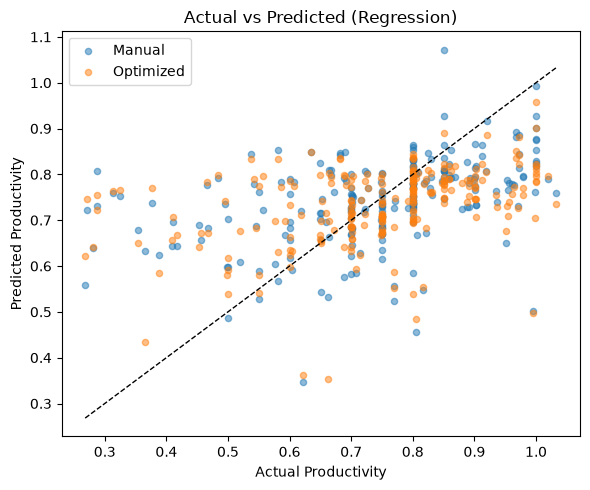

In [69]:
plt.figure(figsize=(6, 5))
plt.scatter(y_reg_test_np, y_reg_pred_manual, alpha=0.5, label="Manual", s=20)
plt.scatter(y_reg_test_np, y_reg_pred_opt, alpha=0.5, label="Optimized", s=20)
plt.plot([y_reg_test_np.min(), y_reg_test_np.max()],
         [y_reg_test_np.min(), y_reg_test_np.max()], 'k--', linewidth=1)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted (Regression)")
plt.legend()
plt.tight_layout()
plt.show()

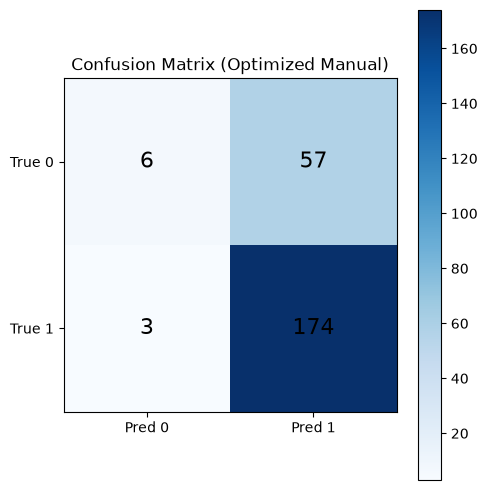

In [70]:
def manual_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return np.array([[tn, fp], [fn, tp]])

cm = manual_confusion_matrix(y_clf_test_np, y_clf_pred_opt)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16)
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.title("Confusion Matrix (Optimized Manual)")
plt.colorbar()
plt.tight_layout()
plt.show()

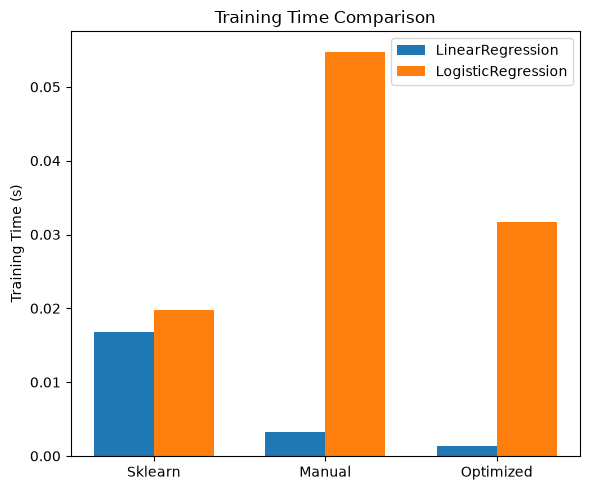

In [71]:
methods = ["Sklearn", "Manual", "Optimized"]
lin_times = [sklearn_results["regression"]["train_time"],
             manual_results["regression"]["train_time"],
             optimized_results["regression"]["train_time"]]
log_times = [sklearn_results["classification"]["train_time"],
             manual_results["classification"]["train_time"],
             optimized_results["classification"]["train_time"]]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(6, 5))
plt.bar(x - width/2, lin_times, width, label="LinearRegression")
plt.bar(x + width/2, log_times, width, label="LogisticRegression")
plt.xticks(x, methods)
plt.ylabel("Training Time (s)")
plt.title("Training Time Comparison")
plt.legend()
plt.tight_layout()
plt.show()